#  Decision Tree Classifier

## Heart Disease Prediction using Decision Tree

Author: Varun Singh

### Objective

Build a Decision Tree Classifier to predict whether a patient has heart disease based on medical features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Create Sample Dataset

In [2]:
data = {
    "Age":[45,50,39,60,35,48,52,43,57,46],
    "BP":[130,140,120,150,110,135,145,125,155,138],
    "Cholesterol":[230,250,180,270,170,220,260,200,280,210],
    "HeartDisease":[1,1,0,1,0,1,1,0,1,0]
}

df = pd.DataFrame(data)

df

,Age,BP,Cholesterol,HeartDisease
0,45,130,230,1
1,50,140,250,1
2,39,120,180,0
3,60,150,270,1
4,35,110,170,0
5,48,135,220,1
6,52,145,260,1
7,43,125,200,0
8,57,155,280,1
9,46,138,210,0


## Explore Dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Age           10 non-null     int64
 1   BP            10 non-null     int64
 2   Cholesterol   10 non-null     int64
 3   HeartDisease  10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes


In [4]:
df.describe()

,Age,BP,Cholesterol,HeartDisease
count,10.000000,10.000000,10.00000,10.000000
mean,47.500000,134.800000,227.00000,0.600000
std,7.677529,13.878841,37.72709,0.516398
min,35.000000,110.000000,170.00000,0.000000
25%,43.500000,126.250000,202.50000,0.000000
50%,47.000000,136.500000,225.00000,1.000000
75%,51.500000,143.750000,257.50000,1.000000
max,60.000000,155.000000,280.00000,1.000000


In [5]:
df.isnull().sum()

,0
Age,0
BP,0
Cholesterol,0
HeartDisease,0


## Split Features and Target

In [6]:
X = df[["Age", "BP", "Cholesterol"]]

y = df["HeartDisease"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train Decision Tree Model

In [8]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## Prediction

In [9]:
y_pred = model.predict(X_test)

y_pred

array([1, 1])

## Model Evaluation

In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



## Visualize Decision Tree

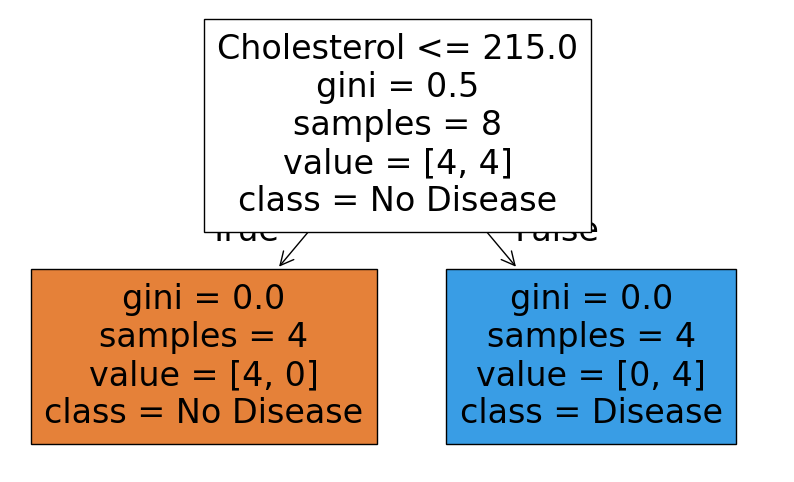

In [14]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10,6))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True
)

plt.show()

## Feature Importance

In [15]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
2,Cholesterol,1.0
0,Age,0.0
1,BP,0.0


## Predict New Patient

In [16]:
new_patient = [[50, 145, 250]]

prediction = model.predict(new_patient)

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")


Heart Disease Detected


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# ✅ Key Learnings

- Created a Decision Tree Classifier
- Split dataset into training and testing sets
- Trained the model
- Predicted outcomes
- Evaluated accuracy
- Generated confusion matrix
- Visualized the decision tree
- Checked feature importance
- Predicted a new patient's result

Decision Trees are powerful, easy to interpret, and useful for many classification tasks.